In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_obs_cohort_lee = pd.read_csv('../../data/lee_obs_cohort.csv')
df_pred_cohort_lee = pd.read_csv('../../data/lee_forecasts_cohort.csv')
df_obs_cohort_dl = pd.read_csv('../../data/dl_obs_cohort_v2.csv')
df_pred_cohort_dl = pd.read_csv('../../data/dl_forecasts_cohort_v2.csv')
df_pred_cohort_fr = pd.read_csv('../../data/freeze_forecasts_cohort.csv')
df_obs_cohort_fr = pd.read_csv('../../data/freeze_obs_cohort.csv')

In [3]:
print(df_pred_cohort_dl.shape)
print(df_pred_cohort_lee.shape)

(477210, 7)
(476280, 7)


In [34]:
df_obs_cohort_lee[(df_obs_cohort_lee["Year"] == 1937) & (df_obs_cohort_lee["Age"] == 14) & (df_obs_cohort_lee["JumpOffYear"] == 2000)]

,Country,Year,Age,Rate,JumpOffYear,Method,Key
9010,0,1937,14,0.00037,2000,LeeCarter_Log,LeeCarter_Log_0
25558,1,1937,14,0.00015,2000,LeeCarter_Log,LeeCarter_Log_1
42190,2,1937,14,0.00190,2000,LeeCarter_Log,LeeCarter_Log_2
71926,4,1937,14,0.00090,2000,LeeCarter_Log,LeeCarter_Log_4
88558,5,1937,14,0.00007,2000,LeeCarter_Log,LeeCarter_Log_5
109222,7,1937,14,0.00044,2000,LeeCarter_Log,LeeCarter_Log_7
171214,11,1937,14,0.00006,2000,LeeCarter_Log,LeeCarter_Log_11
187846,12,1937,14,0.00013,2000,LeeCarter_Log,LeeCarter_Log_12
218842,14,1937,14,0.00010,2000,LeeCarter_Log,LeeCarter_Log_14
235474,15,1937,14,0.00042,2000,LeeCarter_Log,LeeCarter_Log_15


In [27]:
df_pred_cohort_lee[(df_pred_cohort_lee["Year"] == 2000) & (df_pred_cohort_lee["Age"] == 29) & (df_pred_cohort_lee["JumpOffYear"] == 2000)]

,Country,Year,Age,Rate,JumpOffYear,Method,Key
8578,0,2000,29,0.090734,2000,LeeCarter_Log,LeeCarter_Log_0
22648,1,2000,29,0.142267,2000,LeeCarter_Log,LeeCarter_Log_1
36778,2,2000,29,0.033308,2000,LeeCarter_Log,LeeCarter_Log_2
49228,3,2000,29,0.035051,2000,LeeCarter_Log,LeeCarter_Log_3
62518,4,2000,29,0.101797,2000,LeeCarter_Log,LeeCarter_Log_4
76648,5,2000,29,0.119600,2000,LeeCarter_Log,LeeCarter_Log_5
84148,6,2000,29,0.055420,2000,LeeCarter_Log,LeeCarter_Log_6
95758,7,2000,29,0.047626,2000,LeeCarter_Log,LeeCarter_Log_7
109168,8,2000,29,0.101990,2000,LeeCarter_Log,LeeCarter_Log_8
122218,9,2000,29,0.100436,2000,LeeCarter_Log,LeeCarter_Log_9


In [4]:
# Compare dl_obs_cohort.csv and lee_obs_cohort.csv
print(f"DL obs shape:  {df_obs_cohort_dl.shape}")
print(f"Lee obs shape: {df_obs_cohort_lee.shape}")
print(f"DL columns:  {list(df_obs_cohort_dl.columns)}")
print(f"Lee columns: {list(df_obs_cohort_lee.columns)}")

# Find common merge keys
merge_cols = ['Age', 'Year', 'Country', 'JumpOffYear']

# Merge to find matching and non-matching rows
comparison = df_obs_cohort_dl.merge(
    df_obs_cohort_lee, on=merge_cols, suffixes=('_dl', '_lee'), how='outer', indicator=True
)

print(f"\n--- Merge results ---")
print(comparison['_merge'].value_counts())

# Rows only in DL
only_dl = comparison[comparison['_merge'] == 'left_only']
print(f"\nRows only in DL obs: {len(only_dl)}")
if len(only_dl) > 0:
    print("Sample rows only in DL:")
    print(only_dl[merge_cols].drop_duplicates().head(20))
    print(f"\nunique_ages = {sorted(only_dl['Age'].unique())}")
    print(f"unique_countries = {sorted(only_dl['Country'].unique())}")
    print(f"unique_years = {sorted(only_dl['Year'].unique())}")
    print(f"unique_jump_off_years = {sorted(only_dl['JumpOffYear'].unique())}")

# Rows only in Lee
only_lee = comparison[comparison['_merge'] == 'right_only']
print(f"\nRows only in Lee obs: {len(only_lee)}")
if len(only_lee) > 0:
    print("Sample rows only in Lee:")
    print(only_lee[merge_cols].drop_duplicates().head(20))
    print(f"\nunique_ages = {sorted(only_lee['Age'].unique())}")
    print(f"unique_countries = {sorted(only_lee['Country'].unique())}")
    print(f"unique_years = {sorted(only_lee['Year'].unique())}")
    print(f"unique_jump_off_years = {sorted(only_lee['JumpOffYear'].unique())}")

# For matched rows, compare Rate values
matched = comparison[comparison['_merge'] == 'both'].copy()
print(f"\nMatched rows: {len(matched)}")

# Check if Rate columns exist and compare
rate_cols_dl = [c for c in matched.columns if 'Rate' in c and '_dl' in c]
rate_cols_lee = [c for c in matched.columns if 'Rate' in c and '_lee' in c]
print(f"Rate columns DL: {rate_cols_dl}")
print(f"Rate columns Lee: {rate_cols_lee}")

if rate_cols_dl and rate_cols_lee:
    rate_dl_col = rate_cols_dl[0]
    rate_lee_col = rate_cols_lee[0]
    matched['rate_diff'] = matched[rate_dl_col] - matched[rate_lee_col]
    exact_match = (matched['rate_diff'].abs() < 1e-10).sum()
    close_match = (matched['rate_diff'].abs() < 1e-5).sum()
    differ = (matched['rate_diff'].abs() >= 1e-5).sum()
    print(f"\nRate comparison for matched rows:")
    print(f"  Exact match (diff < 1e-10): {exact_match}")
    print(f"  Close match (diff < 1e-5):  {close_match}")
    print(f"  Different (diff >= 1e-5):   {differ}")
    if differ > 0:
        print("\nSample differing rows:")
        differing = matched[matched['rate_diff'].abs() >= 1e-5]
        print(differing[merge_cols + [rate_dl_col, rate_lee_col, 'rate_diff']].head(20))

# Compare unique values in key columns
for col in merge_cols:
    dl_vals = set(df_obs_cohort_dl[col].unique())
    lee_vals = set(df_obs_cohort_lee[col].unique())
    only_in_dl = dl_vals - lee_vals
    only_in_lee = lee_vals - dl_vals
    if only_in_dl or only_in_lee:
        print(f"\n{col} differences:")
        if only_in_dl:
            print(f"  Only in DL: {sorted(only_in_dl)}")
        if only_in_lee:
            print(f"  Only in Lee: {sorted(only_in_lee)}")

DL obs shape:  (390420, 7)
Lee obs shape: (545916, 7)
DL columns:  ['Country', 'Year', 'Age', 'Rate', 'JumpOffYear', 'Method', 'Key']
Lee columns: ['Country', 'Year', 'Age', 'Rate', 'JumpOffYear', 'Method', 'Key']

--- Merge results ---
_merge
both          389940
right_only    155976
left_only        480
Name: count, dtype: int64

Rows only in DL obs: 480
Sample rows only in DL:
       Age  Year  Country  JumpOffYear
35578   15  1985       26         2000
35803   15  1986       26         2000
36028   15  1987       26         2000
36253   15  1988       26         2000
36478   15  1989       26         2000
36703   15  1990       26         2000
36928   15  1991       26         2000
37153   15  1992       26         2000
37378   15  1993       26         2000
37603   15  1994       26         2000
37828   15  1995       26         2000
38053   15  1996       26         2000
38278   15  1997       26         2000
38503   15  1998       26         2000
38728   15  1999       26       

In [5]:
# Find common merge keys across all four files
merge_keys = ['Age', 'Year', 'Country', 'JumpOffYear']

keys_obs_lee = df_obs_cohort_lee[merge_keys].drop_duplicates()
keys_pred_lee = df_pred_cohort_lee[merge_keys].drop_duplicates()
keys_obs_dl = df_obs_cohort_dl[merge_keys].drop_duplicates()
keys_pred_dl = df_pred_cohort_dl[merge_keys].drop_duplicates()
keys_obs_fr = df_obs_cohort_fr[merge_keys].drop_duplicates()
keys_pred_fr = df_pred_cohort_fr[merge_keys].drop_duplicates()

# Intersect all four sets of keys
common_keys = keys_obs_lee.merge(keys_pred_lee, on=merge_keys) \
                          .merge(keys_obs_dl, on=merge_keys) \
                          .merge(keys_pred_dl, on=merge_keys) \
                          .merge(keys_obs_fr, on=merge_keys) \
                          .merge(keys_pred_fr, on=merge_keys)

print(f"Common keys across all 4 files: {len(common_keys):,}")
print(f"Keys in Lee obs:  {len(keys_obs_lee):,}")
print(f"Keys in Lee pred: {len(keys_pred_lee):,}")
print(f"Keys in DL obs:   {len(keys_obs_dl):,}")
print(f"Keys in DL pred:  {len(keys_pred_dl):,}")
print(f"Keys in Freeze obs:   {len(keys_obs_fr):,}")
print(f"Keys in Freeze pred:  {len(keys_pred_fr):,}")

Common keys across all 4 files: 389,940
Keys in Lee obs:  545,916
Keys in Lee pred: 476,280
Keys in DL obs:   390,420
Keys in DL pred:  477,210
Keys in Freeze obs:   545,916
Keys in Freeze pred:  476,280


In [6]:
# Lee-Carter metrics (filtered to common keys)
df_merged_lee = df_obs_cohort_lee.merge(
    df_pred_cohort_lee, on=merge_keys, suffixes=('_obs', '_pred')
)
df_merged_lee = common_keys.merge(df_merged_lee, on=merge_keys)
df_merged_lee = df_merged_lee.dropna(subset=['Rate_obs', 'Rate_pred'])

errors = df_merged_lee['Rate_pred'] - df_merged_lee['Rate_obs']
abs_errors = errors.abs()

mae = abs_errors.mean()
mse = (errors ** 2).mean()
rmse = np.sqrt(mse)
mape = (abs_errors / df_merged_lee['Rate_obs'].replace(0, np.nan)).dropna().mean() * 100
me = errors.mean()

print("=== Lee-Carter (common keys only) ===")
print(f"Matched observations: {len(df_merged_lee):,}")
print(f"MAE:  {mae:.6f}")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"ME:   {me:.6f}  (bias)")
print(f"MAPE: {mape:.2f}%")

metrics_by_joy = df_merged_lee.groupby('JumpOffYear').apply(
    lambda g: pd.Series({
        'MAE': (g['Rate_pred'] - g['Rate_obs']).abs().mean(),
        'MSE': ((g['Rate_pred'] - g['Rate_obs']) ** 2).mean(),
        'RMSE': np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()),
        'ME': (g['Rate_pred'] - g['Rate_obs']).mean(),
        'N': len(g),
    })
)
print("\n--- By JumpOffYear ---")
print(metrics_by_joy.to_string())

metrics_by_country = df_merged_lee.groupby('Country').apply(
    lambda g: pd.Series({
        'MAE': (g['Rate_pred'] - g['Rate_obs']).abs().mean(),
        'MSE': ((g['Rate_pred'] - g['Rate_obs']) ** 2).mean(),
        'RMSE': np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()),
        'ME': (g['Rate_pred'] - g['Rate_obs']).mean(),
        'N': len(g),
    })
)
print("\n--- By Country ---")
print(metrics_by_country.to_string())

=== Lee-Carter (common keys only) ===
Matched observations: 389,940
MAE:  0.004706
MSE:  0.000243
RMSE: 0.015585
ME:   0.000408  (bias)
MAPE: 12.56%

--- By JumpOffYear ---
                  MAE       MSE      RMSE        ME        N
JumpOffYear                                                 
1985         0.011119  0.000683  0.026135  0.001576  64200.0
1990         0.008219  0.000473  0.021737  0.002965  64200.0
1995         0.004801  0.000228  0.015099 -0.001062  64920.0
2000         0.002713  0.000065  0.008081 -0.000540  64920.0
2005         0.001227  0.000019  0.004303 -0.000583  65850.0
2010         0.000378  0.000004  0.002008  0.000152  65850.0

--- By Country ---
              MAE       MSE      RMSE        ME        N
Country                                                 
0        0.003431  0.000108  0.010383 -0.000866  11700.0
1        0.003262  0.000097  0.009832 -0.000667  11880.0
2        0.005742  0.000380  0.019501  0.001124  11880.0
3        0.007789  0.000591  0.024

In [7]:
# DL metrics (filtered to common keys)
df_merged_dl = df_obs_cohort_dl.merge(
    df_pred_cohort_dl, on=merge_keys, suffixes=('_obs', '_pred')
)
df_merged_dl = common_keys.merge(df_merged_dl, on=merge_keys)
df_merged_dl = df_merged_dl.dropna(subset=['Rate_obs', 'Rate_pred'])

errors = df_merged_dl['Rate_pred'] - df_merged_dl['Rate_obs']
abs_errors = errors.abs()

mae = abs_errors.mean()
mse = (errors ** 2).mean()
rmse = np.sqrt(mse)
mape = (abs_errors / df_merged_dl['Rate_obs'].replace(0, np.nan)).dropna().mean() * 100
me = errors.mean()

print("=== Deep Learning (common keys only) ===")
print(f"Matched observations: {len(df_merged_dl):,}")
print(f"MAE:  {mae:.6f}")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"ME:   {me:.6f}  (bias)")
print(f"MAPE: {mape:.2f}%")

metrics_by_joy = df_merged_dl.groupby('JumpOffYear').apply(
    lambda g: pd.Series({
        'MAE': (g['Rate_pred'] - g['Rate_obs']).abs().mean(),
        'MSE': ((g['Rate_pred'] - g['Rate_obs']) ** 2).mean(),
        'RMSE': np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()),
        'ME': (g['Rate_pred'] - g['Rate_obs']).mean(),
        'N': len(g),
    })
)
print("\n--- By JumpOffYear ---")
print(metrics_by_joy.to_string())

metrics_by_country = df_merged_dl.groupby('Country').apply(
    lambda g: pd.Series({
        'MAE': (g['Rate_pred'] - g['Rate_obs']).abs().mean(),
        'MSE': ((g['Rate_pred'] - g['Rate_obs']) ** 2).mean(),
        'RMSE': np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()),
        'ME': (g['Rate_pred'] - g['Rate_obs']).mean(),
        'N': len(g),
    })
)
print("\n--- By Country ---")
print(metrics_by_country.to_string())

=== Deep Learning (common keys only) ===
Matched observations: 389,940
MAE:  0.004057
MSE:  0.000132
RMSE: 0.011505
ME:   -0.000652  (bias)
MAPE: 20.26%

--- By JumpOffYear ---
                  MAE       MSE      RMSE        ME        N
JumpOffYear                                                 
1985         0.011564  0.000490  0.022137 -0.001476  64200.0
1990         0.004920  0.000142  0.011932  0.001085  64200.0
1995         0.003744  0.000091  0.009557 -0.001193  64920.0
2000         0.002357  0.000048  0.006954 -0.001405  64920.0
2005         0.001506  0.000025  0.005040 -0.001008  65850.0
2010         0.000434  0.000004  0.002040  0.000092  65850.0

--- By Country ---
              MAE       MSE      RMSE        ME        N
Country                                                 
0        0.002564  0.000054  0.007345  0.000117  11700.0
1        0.003522  0.000124  0.011132 -0.001595  11880.0
2        0.003768  0.000114  0.010690 -0.000416  11880.0
3        0.004648  0.000132  0

In [8]:
# DL metrics (filtered to common keys)
df_merged_fr = df_obs_cohort_fr.merge(
    df_pred_cohort_fr, on=merge_keys, suffixes=('_obs', '_pred')
)
df_merged_fr = common_keys.merge(df_merged_fr, on=merge_keys)
df_merged_fr = df_merged_fr.dropna(subset=['Rate_obs', 'Rate_pred'])

errors = df_merged_fr['Rate_pred'] - df_merged_fr['Rate_obs']
abs_errors = errors.abs()

mae = abs_errors.mean()
mse = (errors ** 2).mean()
rmse = np.sqrt(mse)
mape = (abs_errors / df_merged_fr['Rate_obs'].replace(0, np.nan)).dropna().mean() * 100
me = errors.mean()

print("=== Freeze Rates (common keys only) ===")
print(f"Matched observations: {len(df_merged_fr):,}")
print(f"MAE:  {mae:.6f}")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"ME:   {me:.6f}  (bias)")
print(f"MAPE: {mape:.2f}%")

metrics_by_joy = df_merged_fr.groupby('JumpOffYear').apply(
    lambda g: pd.Series({
        'MAE': (g['Rate_pred'] - g['Rate_obs']).abs().mean(),
        'MSE': ((g['Rate_pred'] - g['Rate_obs']) ** 2).mean(),
        'RMSE': np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()),
        'ME': (g['Rate_pred'] - g['Rate_obs']).mean(),
        'N': len(g),
    })
)
print("\n--- By JumpOffYear ---")
print(metrics_by_joy.to_string())

metrics_by_country = df_merged_fr.groupby('Country').apply(
    lambda g: pd.Series({
        'MAE': (g['Rate_pred'] - g['Rate_obs']).abs().mean(),
        'MSE': ((g['Rate_pred'] - g['Rate_obs']) ** 2).mean(),
        'RMSE': np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()),
        'ME': (g['Rate_pred'] - g['Rate_obs']).mean(),
        'N': len(g),
    })
)
print("\n--- By Country ---")
print(metrics_by_country.to_string())

=== Freeze Rates (common keys only) ===
Matched observations: 389,940
MAE:  0.004325
MSE:  0.000179
RMSE: 0.013381
ME:   0.000893  (bias)
MAPE: 10.55%

--- By JumpOffYear ---
                  MAE       MSE      RMSE        ME        N
JumpOffYear                                                 
1985         0.010119  0.000521  0.022832  0.003385  64200.0
1990         0.007577  0.000357  0.018886  0.002995  64200.0
1995         0.004367  0.000131  0.011431 -0.000063  64920.0
2000         0.002539  0.000056  0.007460 -0.000466  64920.0
2005         0.001191  0.000017  0.004163 -0.000504  65850.0
2010         0.000358  0.000003  0.001810  0.000092  65850.0

--- By Country ---
              MAE       MSE      RMSE        ME        N
Country                                                 
0        0.003236  0.000082  0.009064  0.000140  11700.0
1        0.003279  0.000094  0.009716 -0.000981  11880.0
2        0.004716  0.000253  0.015890  0.001586  11880.0
3        0.005625  0.000255  0.0

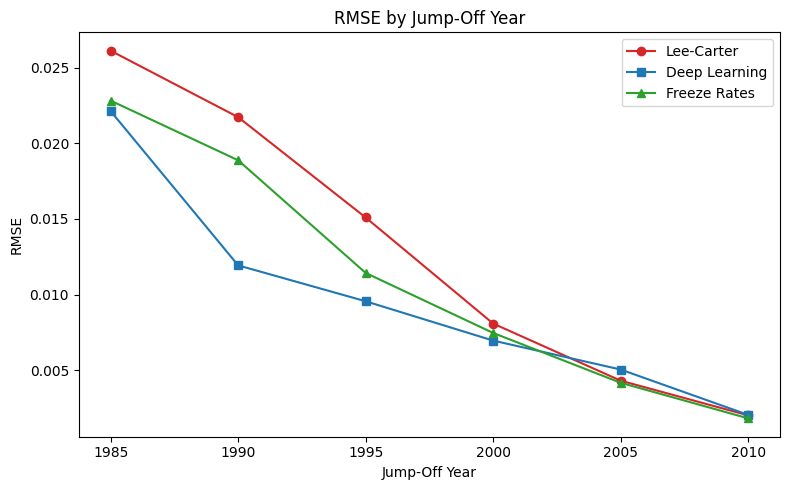

In [9]:
# RMSE by Jump-Off Year: DL vs Lee-Carter
rmse_lee = df_merged_lee.groupby('JumpOffYear').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean())
)
rmse_dl = df_merged_dl.groupby('JumpOffYear').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean())
)

rmse_fr = df_merged_fr.groupby('JumpOffYear').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean())
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rmse_lee.index, rmse_lee.values, 'o-', label='Lee-Carter', color='#d62728')
ax.plot(rmse_dl.index, rmse_dl.values, 's-', label='Deep Learning', color='#1f77b4')
ax.plot(rmse_fr.index, rmse_fr.values, '^-', label='Freeze Rates', color='#2ca02c') 
ax.set_xlabel('Jump-Off Year')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Jump-Off Year')
ax.legend()
ax.set_xticks(rmse_lee.index)
plt.tight_layout()
plt.show()

In [10]:
# DIAGNOSTIC: Check dilution by non-forecasted cells
# In cohort format, Year = birth year. The underlying period year = Year + Age.
# If period_year <= JOY, the "predicted" rate is just the observed rate (zero error).
# These zero-error cells dilute the RMSE and make all methods converge.

print("=" * 70)
print("DILUTION DIAGNOSTIC: Fraction of cells with NO actual forecast")
print("=" * 70)

for joy in sorted(df_merged_lee['JumpOffYear'].unique()):
    subset = df_merged_lee[df_merged_lee['JumpOffYear'] == joy]
    period_year = subset['Year'] + subset['Age']
    n_total = len(subset)
    n_observed = (period_year <= joy).sum()  # these have zero error by construction
    n_forecast = (period_year > joy).sum()   # these are actual forecasts
    pct_observed = 100 * n_observed / n_total
    print(f"JOY={joy}: {n_total:,} total cells, "
          f"{n_observed:,} observed ({pct_observed:.1f}%), "
          f"{n_forecast:,} forecasted ({100-pct_observed:.1f}%)")

# Verify: for observed cells, pred should exactly equal obs
print("\nVerification: error on observed (non-forecast) cells should be ~0:")
for joy in sorted(df_merged_lee['JumpOffYear'].unique()):
    subset = df_merged_lee[df_merged_lee['JumpOffYear'] == joy]
    period_year = subset['Year'] + subset['Age']
    obs_cells = subset[period_year <= joy]
    if len(obs_cells) > 0:
        mae_obs = (obs_cells['Rate_pred'] - obs_cells['Rate_obs']).abs().mean()
        print(f"  JOY={joy} Lee-Carter observed-cell MAE: {mae_obs:.8f}")

    subset_dl = df_merged_dl[df_merged_dl['JumpOffYear'] == joy]
    period_year_dl = subset_dl['Year'] + subset_dl['Age']
    obs_cells_dl = subset_dl[period_year_dl <= joy]
    if len(obs_cells_dl) > 0:
        mae_obs_dl = (obs_cells_dl['Rate_pred'] - obs_cells_dl['Rate_obs']).abs().mean()
        print(f"  JOY={joy} DL observed-cell MAE:         {mae_obs_dl:.8f}")

DILUTION DIAGNOSTIC: Fraction of cells with NO actual forecast
JOY=1985: 64,200 total cells, 31,890 observed (49.7%), 32,310 forecasted (50.3%)
JOY=1990: 64,200 total cells, 37,290 observed (58.1%), 26,910 forecasted (41.9%)
JOY=1995: 64,920 total cells, 42,810 observed (65.9%), 22,110 forecasted (34.1%)
JOY=2000: 64,920 total cells, 48,360 observed (74.5%), 16,560 forecasted (25.5%)
JOY=2005: 65,850 total cells, 54,240 observed (82.4%), 11,610 forecasted (17.6%)
JOY=2010: 65,850 total cells, 60,090 observed (91.3%), 5,760 forecasted (8.7%)

Verification: error on observed (non-forecast) cells should be ~0:
  JOY=1985 Lee-Carter observed-cell MAE: 0.00000000
  JOY=1985 DL observed-cell MAE:         0.00000000
  JOY=1990 Lee-Carter observed-cell MAE: 0.00000000
  JOY=1990 DL observed-cell MAE:         0.00000000
  JOY=1995 Lee-Carter observed-cell MAE: 0.00000000
  JOY=1995 DL observed-cell MAE:         0.00000000
  JOY=2000 Lee-Carter observed-cell MAE: 0.00000000
  JOY=2000 DL observe

In [15]:
df_merged_lee.head()

,Age,Year,Country,JumpOffYear,Rate_obs,Method_obs,Key_obs,Rate_pred,Method_pred,Key_pred
0,44,1907,0,1985,0.00595,LeeCarter_Log,LeeCarter_Log_0,0.00595,LeeCarter_Log,LeeCarter_Log_0
1,43,1908,0,1985,0.01030,LeeCarter_Log,LeeCarter_Log_0,0.01030,LeeCarter_Log,LeeCarter_Log_0
2,44,1908,0,1985,0.00562,LeeCarter_Log,LeeCarter_Log_0,0.00562,LeeCarter_Log,LeeCarter_Log_0
3,42,1909,0,1985,0.01533,LeeCarter_Log,LeeCarter_Log_0,0.01533,LeeCarter_Log,LeeCarter_Log_0
4,43,1909,0,1985,0.00997,LeeCarter_Log,LeeCarter_Log_0,0.00997,LeeCarter_Log,LeeCarter_Log_0


In [11]:
# CORRECTED COMPARISON: Only evaluate on actual forecast cells (period_year > JOY)
# This removes the zero-error observed cells that dilute the comparison.

def compute_forecast_only_metrics(df_merged, method_name):
    """Filter to only cells where the period year exceeds JOY (actual forecasts)."""
    df = df_merged.copy()
    df['period_year'] = df['Year'] + df['Age']
    df_forecast = df[df['period_year'] > df['JumpOffYear']]

    errors = df_forecast['Rate_pred'] - df_forecast['Rate_obs']
    overall_rmse = np.sqrt((errors ** 2).mean())
    overall_mae = errors.abs().mean()

    print(f"\n=== {method_name} (FORECAST-ONLY cells) ===")
    print(f"Total cells: {len(df_merged):,} → Forecast cells: {len(df_forecast):,} "
          f"({100*len(df_forecast)/len(df_merged):.1f}%)")
    print(f"Overall RMSE: {overall_rmse:.6f}  MAE: {overall_mae:.6f}")

    by_joy = df_forecast.groupby('JumpOffYear').apply(
        lambda g: pd.Series({
            'RMSE': np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()),
            'MAE': (g['Rate_pred'] - g['Rate_obs']).abs().mean(),
            'N_forecast': len(g),
            'N_total': len(df_merged[df_merged['JumpOffYear'] == g.name]),
            'Pct_forecast': 100 * len(g) / len(df_merged[df_merged['JumpOffYear'] == g.name]),
        })
    )
    print("\n--- By JumpOffYear (forecast-only) ---")
    print(by_joy.to_string())
    return df_forecast, by_joy

print("Columns:", df_merged_lee.columns.tolist())
print("Index Name:", df_merged_lee.index.name)

df_forecast_lee, joy_lee = compute_forecast_only_metrics(df_merged_lee, "Lee-Carter")
df_forecast_dl, joy_dl = compute_forecast_only_metrics(df_merged_dl, "Deep Learning")
df_forecast_fr, joy_fr = compute_forecast_only_metrics(df_merged_fr, "Freeze Rates")

Columns: ['Age', 'Year', 'Country', 'JumpOffYear', 'Rate_obs', 'Method_obs', 'Key_obs', 'Rate_pred', 'Method_pred', 'Key_pred']
Index Name: None

=== Lee-Carter (FORECAST-ONLY cells) ===
Total cells: 389,940 → Forecast cells: 115,260 (29.6%)
Overall RMSE: 0.028665  MAE: 0.015922

--- By JumpOffYear (forecast-only) ---
                 RMSE       MAE  N_forecast  N_total  Pct_forecast
JumpOffYear                                                       
1985         0.036840  0.022094     32310.0  64200.0     50.327103
1990         0.033575  0.019609     26910.0  64200.0     41.915888
1995         0.025873  0.014097     22110.0  64920.0     34.057301
2000         0.016000  0.010638     16560.0  64920.0     25.508318
2005         0.010247  0.006962     11610.0  65850.0     17.630979
2010         0.006788  0.004324      5760.0  65850.0      8.747153

=== Deep Learning (FORECAST-ONLY cells) ===
Total cells: 389,940 → Forecast cells: 115,260 (29.6%)
Overall RMSE: 0.021162  MAE: 0.013727

--- B

In [17]:
df_forecast_dl.head()

,Age,Year,Country,JumpOffYear,Rate_obs,Method_obs,Key_obs,Rate_pred,Method_pred,Key_pred,period_year
644,44,1942,0,1985,0.00118,DL_NonLog,DL_NonLog_0,0.001243,DL_NonLog,DL_NonLog_0,1986
673,43,1943,0,1985,0.00192,DL_NonLog,DL_NonLog_0,0.001893,DL_NonLog,DL_NonLog_0,1986
674,44,1943,0,1985,0.00153,DL_NonLog,DL_NonLog_0,0.001224,DL_NonLog,DL_NonLog_0,1987
702,42,1944,0,1985,0.00274,DL_NonLog,DL_NonLog_0,0.003122,DL_NonLog,DL_NonLog_0,1986
703,43,1944,0,1985,0.00164,DL_NonLog,DL_NonLog_0,0.001860,DL_NonLog,DL_NonLog_0,1987


In [12]:
# DIAGNOSTIC 2: Check the observed data for suspicious patterns
# What is the max period year (Year + Age) in the obs data?
# If it exceeds the latest year data should be available, something is wrong.

print("=" * 70)
print("DIAGNOSTIC 2: Period year range in observed data")
print("=" * 70)

for name, df_obs in [("Lee obs", df_obs_cohort_lee), ("DL obs", df_obs_cohort_dl), ("Freeze obs", df_obs_cohort_fr)]:
    df_obs = df_obs.copy()
    df_obs['period_year'] = df_obs['Year'] + df_obs['Age']
    print(f"\n{name}:")
    print(f"  Birth year range: {df_obs['Year'].min()} - {df_obs['Year'].max()}")
    print(f"  Age range: {df_obs['Age'].min()} - {df_obs['Age'].max()}")
    print(f"  Period year range: {df_obs['period_year'].min()} - {df_obs['period_year'].max()}")
    
    # For each JOY, what's the max period year in the obs data?
    for joy in sorted(df_obs['JumpOffYear'].unique()):
        subset = df_obs[df_obs['JumpOffYear'] == joy]
        subset_period = subset['Year'] + subset['Age']
        max_py = subset_period.max()
        # How many cells have period_year > some reasonable cutoff (e.g., 2020)?
        n_beyond_2020 = (subset_period > 2020).sum()
        print(f"  JOY={joy}: max period_year={max_py}, cells with period_year>2020: {n_beyond_2020}")

# Check: for forecast cells (period_year > JOY), are any obs rates exactly 0?
print("\n" + "=" * 70)
print("DIAGNOSTIC 3: Zero or suspicious observed rates in FORECAST cells")
print("=" * 70)

for name, df_merged in [("Lee", df_merged_lee), ("DL", df_merged_dl), ("Freeze", df_merged_fr)]:
    df = df_merged.copy()
    df['period_year'] = df['Year'] + df['Age']
    forecast = df[df['period_year'] > df['JumpOffYear']]
    
    n_zero = (forecast['Rate_obs'] == 0).sum()
    n_near_zero = (forecast['Rate_obs'] < 1e-5).sum()
    n_negative = (forecast['Rate_obs'] < 0).sum()
    n_nan = forecast['Rate_obs'].isna().sum()
    
    print(f"\n{name} forecast cells ({len(forecast):,} total):")
    print(f"  Rate_obs == 0:    {n_zero:,}")
    print(f"  Rate_obs < 1e-5:  {n_near_zero:,}")
    print(f"  Rate_obs < 0:     {n_negative:,}")
    print(f"  Rate_obs is NaN:  {n_nan:,}")
    print(f"  Rate_obs summary:\n{forecast['Rate_obs'].describe()}")


DIAGNOSTIC 2: Period year range in observed data

Lee obs:
  Birth year range: 1896 - 2002
  Age range: 13 - 54
  Period year range: 1950 - 2015
  JOY=1985: max period_year=2015, cells with period_year>2020: 0
  JOY=1990: max period_year=2015, cells with period_year>2020: 0
  JOY=1995: max period_year=2015, cells with period_year>2020: 0
  JOY=2000: max period_year=2015, cells with period_year>2020: 0
  JOY=2005: max period_year=2015, cells with period_year>2020: 0
  JOY=2010: max period_year=2015, cells with period_year>2020: 0

DL obs:
  Birth year range: 1906 - 2000
  Age range: 15 - 44
  Period year range: 1950 - 2015
  JOY=1985: max period_year=2015, cells with period_year>2020: 0
  JOY=1990: max period_year=2015, cells with period_year>2020: 0
  JOY=1995: max period_year=2015, cells with period_year>2020: 0
  JOY=2000: max period_year=2015, cells with period_year>2020: 0
  JOY=2005: max period_year=2015, cells with period_year>2020: 0
  JOY=2010: max period_year=2015, cells with 

DIAGNOSTIC 4: Do observed rates differ across JOY for same cell?

Lee obs:
  Total (Country, Year, Age) groups: 92,190
  Groups where Rate varies across JOY: 0

DL obs:
  Total (Country, Year, Age) groups: 65,850
  Groups where Rate varies across JOY: 0

DIAGNOSTIC 5: Forecast horizon distribution

Horizon stats across all JOYs:
             min   max       mean   50%
JumpOffYear                            
1985         1.0  30.0  15.460539  15.0
1990         1.0  25.0  12.960981  13.0
1995         1.0  20.0  10.462687  10.0
2000         1.0  15.0   7.963768   8.0
2005         1.0  10.0   5.467700   5.0
2010         1.0   5.0   2.973958   3.0


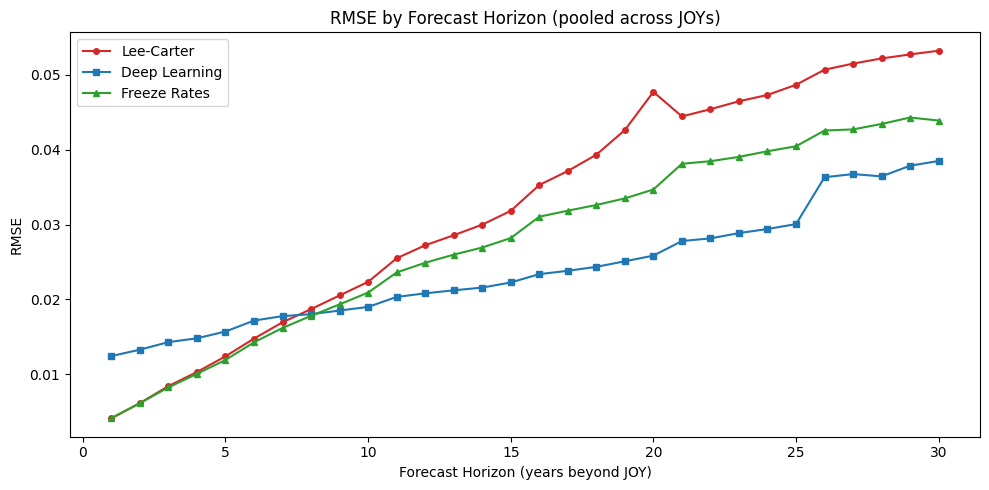

In [13]:
# DIAGNOSTIC 4: Check if obs rates vary across JOY for the SAME (Country, Year, Age) cell
# If observed rates are truly observed, they should be identical across JOY values.
# If they differ, it means the obs data is being generated differently per JOY (suspicious).

print("=" * 70)
print("DIAGNOSTIC 4: Do observed rates differ across JOY for same cell?")
print("=" * 70)

for name, df_obs in [("Lee obs", df_obs_cohort_lee), ("DL obs", df_obs_cohort_dl)]:
    # Group by (Country, Year, Age) and check if Rate varies across JumpOffYear
    rate_variation = df_obs.groupby(['Country', 'Year', 'Age'])['Rate'].nunique()
    n_varying = (rate_variation > 1).sum()
    n_total_groups = len(rate_variation)
    print(f"\n{name}:")
    print(f"  Total (Country, Year, Age) groups: {n_total_groups:,}")
    print(f"  Groups where Rate varies across JOY: {n_varying:,}")
    if n_varying > 0:
        # Show some examples
        varying_keys = rate_variation[rate_variation > 1].head(5).index.tolist()
        for key in varying_keys:
            c, y, a = key
            rows = df_obs[(df_obs['Country'] == c) & (df_obs['Year'] == y) & (df_obs['Age'] == a)]
            print(f"\n  Example: Country={c}, Year={y}, Age={a}")
            print(rows[['JumpOffYear', 'Rate']].to_string(index=False))

# DIAGNOSTIC 5: For forecast-only cells, check the horizon distribution
# Horizon = period_year - JOY (how far into the future the forecast is)
print("\n" + "=" * 70)
print("DIAGNOSTIC 5: Forecast horizon distribution")
print("=" * 70)

df = df_merged_lee.copy()
df['period_year'] = df['Year'] + df['Age']
df['horizon'] = df['period_year'] - df['JumpOffYear']
forecast = df[df['horizon'] > 0]

print(f"\nHorizon stats across all JOYs:")
print(forecast.groupby('JumpOffYear')['horizon'].describe()[['min', 'max', 'mean', '50%']].to_string())

# RMSE by horizon (pooled across JOYs)
rmse_by_horizon_lee = forecast.groupby('horizon').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()))

df2 = df_merged_dl.copy()
df2['period_year'] = df2['Year'] + df2['Age']
df2['horizon'] = df2['period_year'] - df2['JumpOffYear']
forecast_dl = df2[df2['horizon'] > 0]
rmse_by_horizon_dl = forecast_dl.groupby('horizon').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()))

df3 = df_merged_fr.copy()
df3['period_year'] = df3['Year'] + df3['Age']
df3['horizon'] = df3['period_year'] - df3['JumpOffYear']
forecast_fr = df3[df3['horizon'] > 0]
rmse_by_horizon_fr = forecast_fr.groupby('horizon').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rmse_by_horizon_lee.index, rmse_by_horizon_lee.values, 'o-', label='Lee-Carter', color='#d62728', markersize=4)
ax.plot(rmse_by_horizon_dl.index, rmse_by_horizon_dl.values, 's-', label='Deep Learning', color='#1f77b4', markersize=4)
ax.plot(rmse_by_horizon_fr.index, rmse_by_horizon_fr.values, '^-', label='Freeze Rates', color='#2ca02c', markersize=4)
ax.set_xlabel('Forecast Horizon (years beyond JOY)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Forecast Horizon (pooled across JOYs)')
ax.legend()
plt.tight_layout()
plt.show()


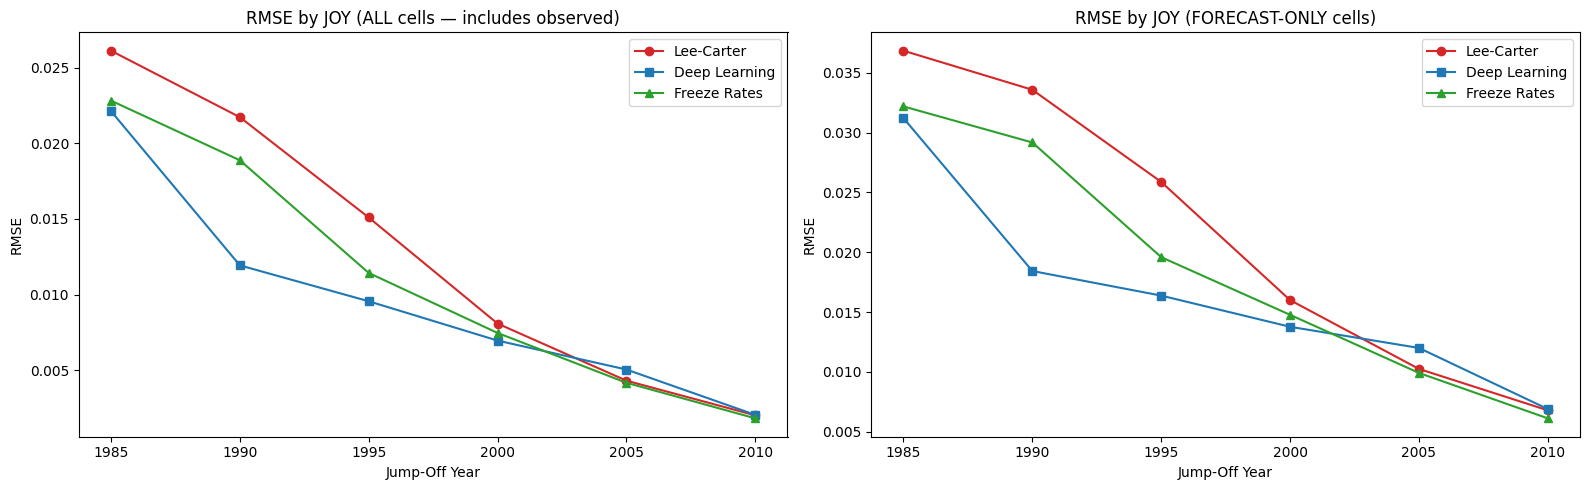

In [14]:
# CORRECTED PLOT: RMSE by JOY using forecast-only cells
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Original (diluted) comparison
ax = axes[0]
rmse_lee_orig = df_merged_lee.groupby('JumpOffYear').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()))
rmse_dl_orig = df_merged_dl.groupby('JumpOffYear').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()))
rmse_fr_orig = df_merged_fr.groupby('JumpOffYear').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean()))
ax.plot(rmse_lee_orig.index, rmse_lee_orig.values, 'o-', label='Lee-Carter', color='#d62728')
ax.plot(rmse_dl_orig.index, rmse_dl_orig.values, 's-', label='Deep Learning', color='#1f77b4')
ax.plot(rmse_fr_orig.index, rmse_fr_orig.values, '^-', label='Freeze Rates', color='#2ca02c')
ax.set_xlabel('Jump-Off Year')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by JOY (ALL cells — includes observed)')
ax.legend()
ax.set_xticks(rmse_lee_orig.index)

# Right: Forecast-only comparison
ax = axes[1]
ax.plot(joy_lee.index, joy_lee['RMSE'].values, 'o-', label='Lee-Carter', color='#d62728')
ax.plot(joy_dl.index, joy_dl['RMSE'].values, 's-', label='Deep Learning', color='#1f77b4')
ax.plot(joy_fr.index, joy_fr['RMSE'].values, '^-', label='Freeze Rates', color='#2ca02c')
ax.set_xlabel('Jump-Off Year')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by JOY (FORECAST-ONLY cells)')
ax.legend()
ax.set_xticks(joy_lee.index)

plt.tight_layout()
plt.show()

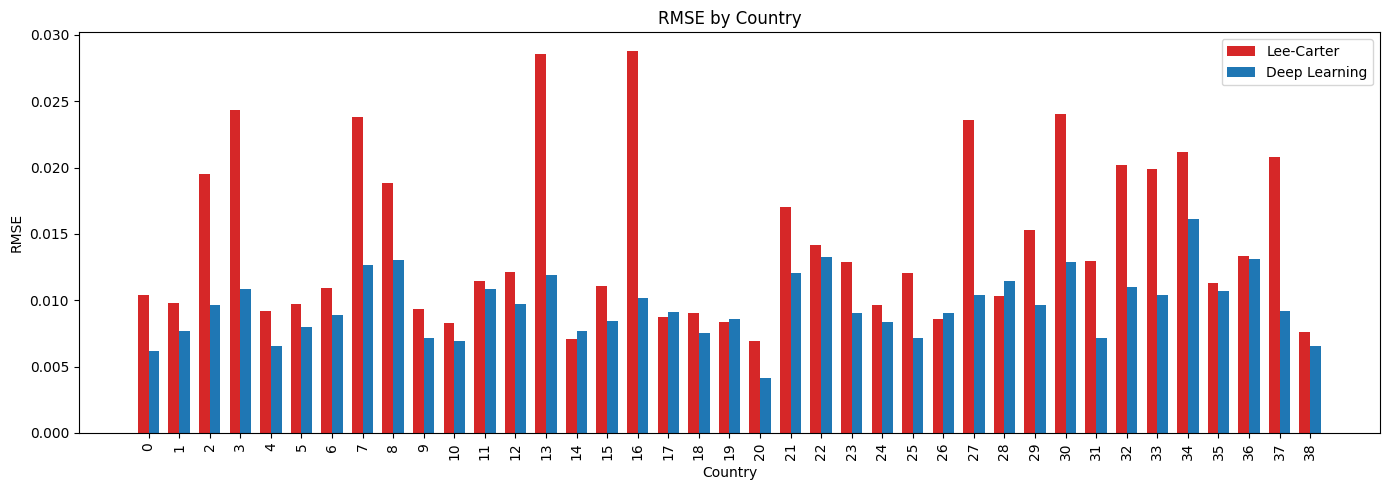

In [19]:
# RMSE by Country: DL vs Lee-Carter
rmse_lee_country = df_merged_lee.groupby('Country').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean())
).sort_index()
rmse_dl_country = df_merged_dl.groupby('Country').apply(
    lambda g: np.sqrt(((g['Rate_pred'] - g['Rate_obs']) ** 2).mean())
).sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(rmse_lee_country))
width = 0.35
ax.bar(x - width/2, rmse_lee_country.values, width, label='Lee-Carter', color='#d62728')
ax.bar(x + width/2, rmse_dl_country.values, width, label='Deep Learning', color='#1f77b4')
ax.set_xlabel('Country')
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Country')
ax.set_xticks(x)
ax.set_xticklabels(rmse_lee_country.index, rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
rmse_lee_2005 = joy_lee.loc[joy_lee.index == 2005, 'RMSE'].values[0]
rmse_fr_2005 = joy_fr.loc[joy_fr.index == 2005, 'RMSE'].values[0]
rmse_dl_2005 = joy_dl.loc[joy_dl.index == 2005, 'RMSE'].values[0]

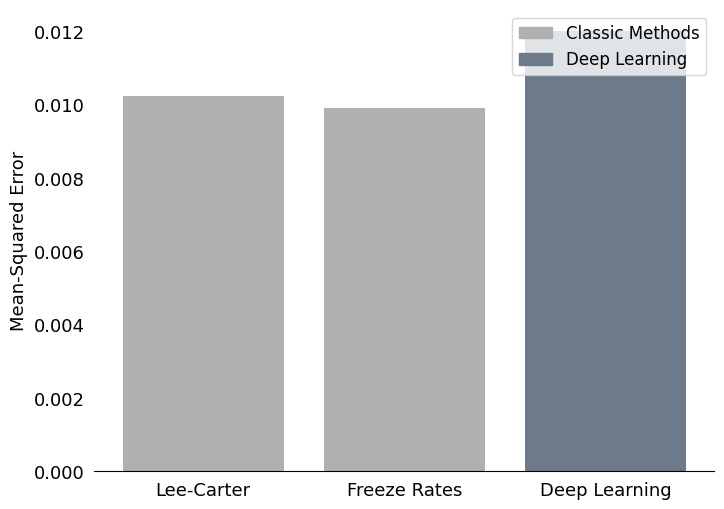

In [17]:
import matplotlib.pyplot as plt
from matplotlib import patches

values = [rmse_lee_2005, rmse_fr_2005, rmse_dl_2005]
labels = ['Lee-Carter', 'Freeze Rates', 'Deep Learning'] 

# Define bar colors: light gray for classic methods, darker gray-blue for DL
bar_colors = ['#B0B0B0', '#B0B0B0', '#6C7A89']

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(labels, values, color=bar_colors)

# Clean axes (matching reference style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False, bottom=False, labelsize=13)

# Bar labels (values on bars)
# for bar in bars:
#     yval = bar.get_height()
#     ax.text(
#         bar.get_x() + bar.get_width() / 2,
#         yval - 0.03,
#         f'{yval:.3f}',
#         ha='center',
#         va='top',
#         fontsize=13,
#         color='white' if yval > 0.15 else 'black'
#     )

# Legend with neutral tones
legend_handles = [
    patches.Patch(color='#B0B0B0', label='Classic Methods'),
    patches.Patch(color='#6C7A89', label='Deep Learning')
]
ax.legend(handles=legend_handles, fontsize=12, loc='upper right')

# Labels
ax.set_ylabel('Mean-Squared Error', fontsize=13)
ax.set_xlabel('')

#plt.tight_layout()
plt.savefig("../prelim_results.pdf", format="pdf", bbox_inches='tight', transparent=True)
plt.show()

In [20]:
joy_lee.head()

,RMSE,MAE,N_forecast,N_total,Pct_forecast
JumpOffYear,,,,,
1985,0.036840,0.022094,32310.0,64200.0,50.327103
1990,0.033575,0.019609,26910.0,64200.0,41.915888
1995,0.025873,0.014097,22110.0,64920.0,34.057301
2000,0.016000,0.010638,16560.0,64920.0,25.508318
2005,0.010247,0.006962,11610.0,65850.0,17.630979


In [22]:
rmse_lee_2005

np.float64(0.010247172233787913)